In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from tqdm import tqdm  # Optional: for progress tracking
from src.utils.Contact_Matrix import create_contact_matrix
from src.utils.visualization.core import create_standalone_colorbar, Lx, Ly, discretize_cmaps

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from bootstrap_CM_module import *



In [2]:
df = pd.read_csv("data_homophily.csv")
df = df.dropna()

mask_distribution = extract_behavior_distribution_vectorized(df, "masks")
test_distribution = extract_behavior_distribution_vectorized(df, "testing")
vaccine_distribution = extract_behavior_distribution_vectorized(df, "vacc")

mask_matrix = generate_contact_matrix(df, "masks")
test_matrix = generate_contact_matrix(df, "testing")
vaccine_matrix = generate_contact_matrix(df, "vacc")

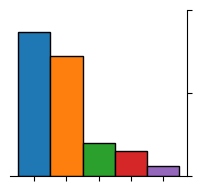

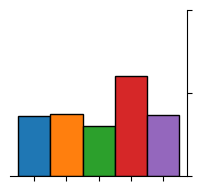

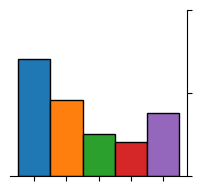

In [3]:
fig, ax = plot_histogram_distribution(mask_distribution, save_path="figures/Fig_2/masks_distribution.pdf")
fig, ax = plot_histogram_distribution(test_distribution, save_path="figures/Fig_2/testing_distribution.pdf")
fig, ax = plot_histogram_distribution(vaccine_distribution, save_path="figures/Fig_2/vaccine_distribution.pdf")

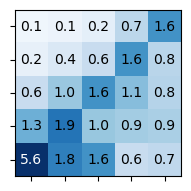

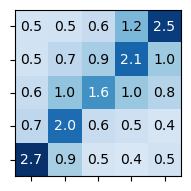

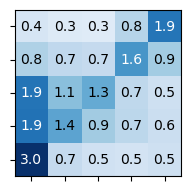

In [4]:
fig, ax = plot_contact_matrix(mask_matrix, Lx, Ly, path="figures/Fig_2/mask_contact_matrix.pdf")
fig, ax = plot_contact_matrix(test_matrix, Lx, Ly, path="figures/Fig_2/testing_contact_matrix.pdf")
fig, ax = plot_contact_matrix(vaccine_matrix, Lx, Ly, path="figures/Fig_2/vaccine_contact_matrix.pdf")

In [ ]:
# calculate and print the range of the confidence interval:
R_M = bootstrap_mph(df, "masks", n_bootstrap=20000)
R_T = bootstrap_mph(df, "testing", n_bootstrap=20000)
R_V = bootstrap_mph(df, "vacc", n_bootstrap=20000)

print(f"[{np.round(R_M['M_CI'], 2)}, {np.round(R_M['P_CI'], 2)}, {np.round(R_M['H_CI'], 2)}]")
print(f"[{np.round(R_T['M_CI'], 2)}, {np.round(R_T['P_CI'], 2)}, {np.round(R_T['H_CI'], 2)}]")
print(f"[{np.round(R_V['M_CI'], 2)}, {np.round(R_V['P_CI'], 2)}, {np.round(R_V['H_CI'], 2)}]")

Bootstrapping MPH for vacc: 100%|██████████| 20000/20000 [00:10<00:00, 1903.62it/s]


In [6]:
print(f"[{np.round(R_M['M_CI'], 2)}, {np.round(R_M['P_CI'], 2)}, {np.round(R_M['H_CI'], 2)}]")
print(f"[{np.round(R_T['M_CI'], 2)}, {np.round(R_T['P_CI'], 2)}, {np.round(R_T['H_CI'], 2)}]")
print(f"[{np.round(R_V['M_CI'], 2)}, {np.round(R_V['P_CI'], 2)}, {np.round(R_V['H_CI'], 2)}]")

[[0.76 0.77 0.79], [0.25 0.28 0.3 ], [1.74 2.58 3.34]]
[[0.45 0.47 0.49], [0.46 0.48 0.5 ], [1.97 2.28 2.58]]
[[0.59 0.61 0.63], [0.55 0.57 0.6 ], [1.36 1.72 2.11]]


In [7]:
print(f"[{np.round(R_M['H'], 2)}]")
print(f"[{np.round(R_T['H'], 2)}]")
print(f"[{np.round(R_V['H'], 2)}]")

[[2.47 2.39 3.26 ... 2.63 2.35 2.78]]
[[2.35 2.04 2.2  ... 2.26 2.44 2.3 ]]
[[2.12 1.75 1.74 ... 1.48 1.53 1.76]]


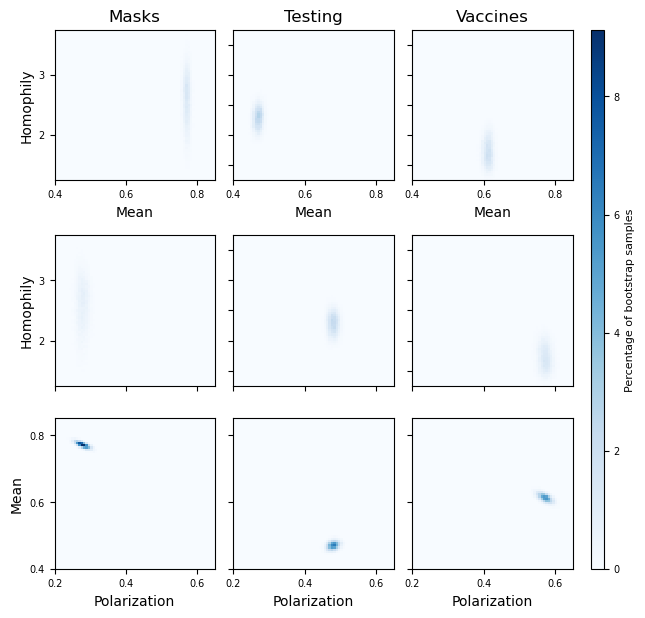

In [15]:
fig, axes = plot_bootstrap_heatmap(R_M, R_T, R_V, bins = 150, figsize=(7.09, 7))
axes[(0,0)].set_title("Masks", fontsize=12)
axes[(0,1)].set_title("Testing", fontsize=12)
axes[(0,2)].set_title("Vaccines", fontsize=12)
for i in range(3):
    axes[(0,i)].set_xlabel("Mean", fontsize=10)
for i in range(2):
    axes[(i,0)].set_ylabel("Homophily", fontsize=10)
axes[(2,0)].set_ylabel("Mean", fontsize=10)
for i in range(3):
    axes[(2,i)].set_xlabel("Polarization", fontsize=10)


for i in range(3):
    axes[(0,i)].set_xlim(0.4, 0.85)
    axes[(1,i)].set_xlim(0.2, 0.65)
    axes[(2,i)].set_xlim(0.2, 0.65)

    axes[(0,i)].set_xticks([0.4, 0.6, 0.8])
    axes[(1,i)].set_xticks([0.2, 0.4,  0.6])
    axes[(2,i)].set_xticks([0.2, 0.4,  0.6])

for i in range(3):
    axes[(0,i)].set_ylim(1.25,3.75)
    axes[(1,i)].set_ylim(1.25,3.75)
    axes[(2,i)].set_ylim(0.4,0.85)
    axes[(2,i)].set_yticks([0.4, 0.6, 0.8])


fig.savefig("Figures/Fig_SI/Fig_SI_bootstrapping.pdf", bbox_inches='tight')